In [72]:
import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

from sklearn.feature_selection import SelectKBest, f_classif

from sklearn import set_config
set_config(display="text")

import matplotlib.pyplot as plt
import seaborn as sns

## Classification

The classification task is to predict whether a hotel booking will be canceled. The target variable, `is_canceled`, is binary: `0` represents a completed booking and `1` represents a canceled booking.

In [ ]:
df = pd.read_csv("data/hotel_bookings_clean.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0,C,C,3,No Deposit,0,Transient,0.0,0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0,C,C,4,No Deposit,0,Transient,0.0,0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,A,C,0,No Deposit,0,Transient,75.0,0,0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,A,A,0,No Deposit,0,Transient,75.0,0,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,A,A,0,No Deposit,0,Transient,98.0,0,1


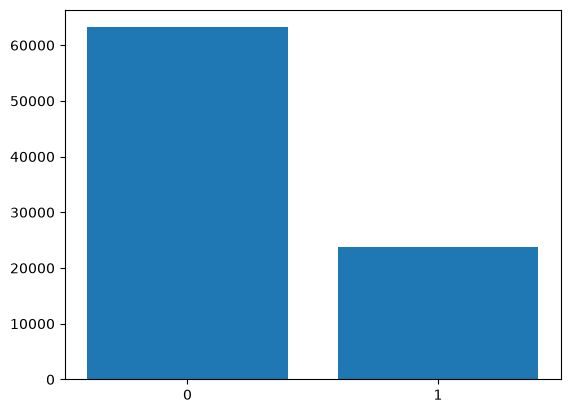

In [74]:
# Visualize count of each class of target
plt.bar(["0", "1"], df["is_canceled"].value_counts().sort_index())
plt.show()

In [75]:
df.nunique()

hotel                                2
is_canceled                          2
lead_time                          479
arrival_date_year                    3
arrival_date_month                  12
arrival_date_week_number            53
arrival_date_day_of_month           31
stays_in_weekend_nights             17
stays_in_week_nights                33
adults                              14
children                             5
babies                               5
meal                                 5
country                            178
market_segment                       7
distribution_channel                 5
is_repeated_guest                    2
previous_cancellations              15
previous_bookings_not_canceled      73
reserved_room_type                   9
assigned_room_type                  11
booking_changes                     19
deposit_type                         3
days_in_waiting_list               127
customer_type                        4
adr                      

In [76]:
# Change non numeric columns to numeric
df = pd.get_dummies(df, drop_first=True)
df

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,assigned_room_type_G,assigned_room_type_H,assigned_room_type_I,assigned_room_type_K,assigned_room_type_L,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
0,0,342,2015,27,1,0,0,2,0.0,0,...,False,False,False,False,False,False,False,False,True,False
1,0,737,2015,27,1,0,0,2,0.0,0,...,False,False,False,False,False,False,False,False,True,False
2,0,7,2015,27,1,0,1,1,0.0,0,...,False,False,False,False,False,False,False,False,True,False
3,0,13,2015,27,1,0,1,1,0.0,0,...,False,False,False,False,False,False,False,False,True,False
4,0,14,2015,27,1,0,2,2,0.0,0,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86934,0,23,2017,35,30,2,5,2,0.0,0,...,False,False,False,False,False,False,False,False,True,False
86935,0,102,2017,35,31,2,5,3,0.0,0,...,False,False,False,False,False,False,False,False,True,False
86936,0,34,2017,35,31,2,5,2,0.0,0,...,False,False,False,False,False,False,False,False,True,False
86937,0,109,2017,35,31,2,5,2,0.0,0,...,False,False,False,False,False,False,False,False,True,False


In [77]:
# Create X and Y
X = df.drop(columns="is_canceled")

y = df["is_canceled"]

In [78]:
# Split into sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [79]:
# Find numeric columns
numeric_cols = X_train.select_dtypes(include="number").columns

In [80]:
# Scale numeric columns only
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [81]:
# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Goes through each model in the dictionary
for name, model in models.items():
    # Cross Validation
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring="accuracy")

    print(f"{name}: {scores.mean():.4f}")

Logistic Regression: 0.7980
KNN: 0.7889
Decision Tree: 0.7828
Random Forest: 0.8380
Gradient Boosting: 0.8182
Naive Bayes: 0.3788


Best first model is Random Forest on CV and actual prediction

## Optimize

In [82]:
# Choose best models and do hyperparameter tuning
parameters = {
    "Random Forest": {
        "n_estimators": [100, 200],
        "max_depth": [10, None],
        "min_samples_leaf": [1, 5]
    },
    "Gradient Boosting": {
        "n_estimators": [100, 200],
        "learning_rate": [0.05, 0.1],
        "max_depth": [2, 3]
    }
}

for name in ["Random Forest", "Gradient Boosting"]:
    # Create grid search to test all combinations of parameters
    grid_search = GridSearchCV(models[name], param_grid=parameters[name], cv=cv, scoring="accuracy")

    # Train each parameter
    grid_search.fit(X_train_scaled, y_train)

    # Print best parameter
    print(name, grid_search.best_params_)

Random Forest {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
Gradient Boosting {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}


In [83]:
# Rerun the models
rf = RandomForestClassifier(max_depth=None, min_samples_leaf=1, n_estimators=200, random_state=42)
gb = GradientBoostingClassifier(learning_rate=0.1, max_depth=3, n_estimators=200, random_state=42)

# Cross Validation
scores_rf = cross_val_score(rf, X_train_scaled, y_train, cv=cv, scoring="accuracy")
scores_gb = cross_val_score(gb, X_train_scaled, y_train, cv=cv, scoring="accuracy")

print(f"Random Forest: {scores_rf.mean():.4f}")
print(f"Gradient Boosting: {scores_gb.mean():.4f}")

Random Forest: 0.8396
Gradient Boosting: 0.8239


In [85]:
# ANOVA
for i in [10, 25, 50, 75, 100, 125, 150, 175, 200]:
    selector = SelectKBest(score_func=f_classif, k=i)

    # Learn which columns to keep from training data only
    selector.fit(X_train_scaled, y_train)
    X_train_selected = selector.transform(X_train_scaled)

    # Cross Validation
    scores_rf = cross_val_score(rf, X_train_selected, y_train, cv=cv, scoring="accuracy")
    scores_gb = cross_val_score(gb, X_train_selected, y_train, cv=cv, scoring="accuracy")

    print(f"Random Forest: {scores_rf.mean():.4f}")
    print(f"Gradient Boosting: {scores_gb.mean():.4f}")

c:\Users\mingj\Desktop\Hotel Regression & Classification\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [ 34  40  49  58  72 100 102 128 154 178] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\mingj\Desktop\Hotel Regression & Classification\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Random Forest: 0.7591
Gradient Boosting: 0.7921


c:\Users\mingj\Desktop\Hotel Regression & Classification\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [ 34  40  49  58  72 100 102 128 154 178] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\mingj\Desktop\Hotel Regression & Classification\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Random Forest: 0.8202
Gradient Boosting: 0.8156


c:\Users\mingj\Desktop\Hotel Regression & Classification\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [ 34  40  49  58  72 100 102 128 154 178] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\mingj\Desktop\Hotel Regression & Classification\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


...

Random Forest: 0.8401
Gradient Boosting: 0.8234


c:\Users\mingj\Desktop\Hotel Regression & Classification\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [ 34  40  49  58  72 100 102 128 154 178] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\mingj\Desktop\Hotel Regression & Classification\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Random Forest: 0.8392
Gradient Boosting: 0.8232


c:\Users\mingj\Desktop\Hotel Regression & Classification\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [ 34  40  49  58  72 100 102 128 154 178] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\mingj\Desktop\Hotel Regression & Classification\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Random Forest: 0.8398
Gradient Boosting: 0.8230


In [86]:
# Final model with hyperparameter tuning and ANOVA
selector = SelectKBest(score_func=f_classif, k=175)
selector.fit(X_train_scaled, y_train)

X_train_selected = selector.transform(X_train_scaled)
X_test_selected = selector.transform(X_test_scaled)

# Train model
rf.fit(X_train_selected, y_train)

# Predict
y_pred_rf = rf.predict(X_test_selected)

c:\Users\mingj\Desktop\Hotel Regression & Classification\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [ 34  40  49  58  72 100 102 128 154 178] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\mingj\Desktop\Hotel Regression & Classification\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


## Evaluate

In [87]:
# Accuracy
print(accuracy_score(y_test, y_pred_rf))

0.842765125373821


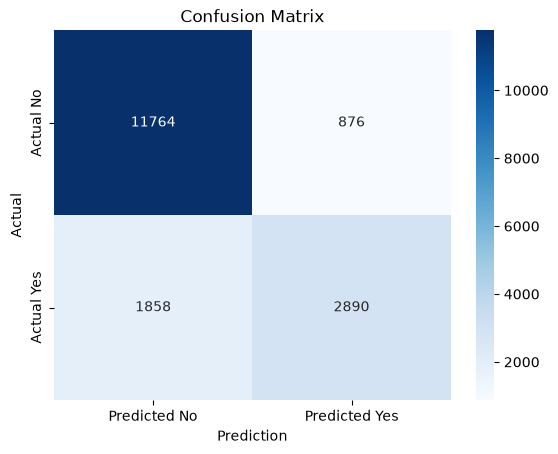

Precision: 0.7673924588422729
Recall: 0.6086773378264533
F1: 0.6788818416725394


In [88]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Predicted No", "Predicted Yes"], yticklabels=["Actual No", "Actual Yes"])
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(f"Precision: {precision_score(y_test, y_pred_rf)}")
print(f"Recall: {recall_score(y_test, y_pred_rf)}")
print(f"F1: {f1_score(y_test, y_pred_rf)}")


No (0): completed booking
Yes (1): canceled

Out of all actual cancellations, it correctly identifies cancellations 60% of the time (recall)

Out of all bookings, it correctly identifies cancellations 76.7% of the time (precision)

Therefore, model is much better at predicting completed bookings also given there are more data points with completed booking. 

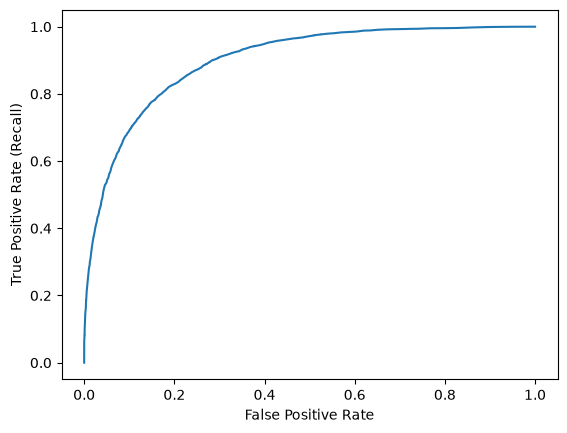

ROC-AUC: 0.8996


In [90]:
# ROC Curve
# Probability that each booking is canceled (class 1)
y_prob = rf.predict_proba(X_test_selected)[:, 1]

# ROC values and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.show()

print(f"ROC-AUC: {auc_score:.4f}")

High ROC-AUC which means strong ability to distinguish canceled from completed bookings. 

Can lower the threshold to catch more cancellations (higher recall) while incorrectly flagging only a few completed bookings as cancellations (low false-positive rate).